In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
import statsmodels.formula.api as smf

sns.set_style("whitegrid")
plt.rcParams['font.sans-serif'] = ['Simhei']  # macOS中文字体
plt.rcParams['axes.unicode_minus'] = False

1. 参数设定

In [20]:
np.random.seed(42)         # 固定随机种子保证可复现
TAU_TRUE = 2.0             # 真实处理效应 (Ground Truth)
N_IND = 1000                # 每个模拟的个体数
N_SIM = 500                # 模拟重复次数 (最低要求500次)

2. 数据生成

In [21]:
def generate_data(scenario="A"):
    """
    生成对应场景的面板数据。
    
    参数:
        scenario (str): "A", "B", 或 "C"
        
    返回:
        pd.DataFrame: 包含 i, t, Y, D, X 的 DataFrame
    """
    # 1. 生成基础变量 (所有场景共用)
    # --------------------------------------
    # X: 处理前可观测协变量 (影响水平，也可能影响趋势)
    X = np.random.normal(0, 1, N_IND)
    
    # 2. 场景特异性设计
    # --------------------------------------
    
    if scenario == "A":
        # 场景 A: 基准情形 (无条件平行趋势成立)
        # 逻辑: 处理分配随机，或仅与不影响趋势的变量相关
        D = np.random.choice([0, 1], size=N_IND, p=[0.5, 0.5]) 
        # 未观测异质性 (不随时间变)
        alpha_i = 0.5 * X 
        # 时间趋势 (对所有人一样)
        lambda_t = lambda t: 1.0 * t
        
    elif scenario == "B":
        # 场景 B: PSM-DID 优于 DID 的情形
        # 逻辑: 处理分配依赖 X，且 X 影响时间趋势 (无条件平行趋势不成立)
        D = (X > 0).astype(int)  # X 高的更可能进入处理组
        alpha_i = 0.5 * X
        # 时间趋势依赖于 X (处理组本身增速就快)
        lambda_t = lambda t, x: 1.0 * t + 0.8 * x * t 
        
    elif scenario == "C":
        # 场景 C: PSM-DID 失败的情形
        # 逻辑: 存在不可观测的时间变化混淆变量 U
        D = (X > 0).astype(int)
        alpha_i = 0.5 * X
        # U: 未观测变量 (既影响选择，又影响结果随时间的变化)
        U = np.random.normal(0, 1, N_IND) 
        # 时间趋势依赖于未观测 U
        lambda_t = lambda t, u: 1.0 * t + 0.8 * u * t 
    else:
        raise ValueError("Scenario must be A, B, or C")

    # 3. 生成潜在结果与观测结果
    # --------------------------------------
    data_list = []
    for i in range(N_IND):
        for t in [0, 1]: # 两期: 0 (前), 1 (后)
            
            # 计算时间固定效应
            if scenario == "A":
                lt = lambda_t(t)
            elif scenario == "B":
                lt = lambda_t(t, X[i])
            elif scenario == "C":
                lt = lambda_t(t, U[i]) # 注意这里用了 U，研究者观测不到
            
            # 潜在结果 Y(0) (不受处理影响的状态)
            Y0 = alpha_i[i] + lt + np.random.normal(0, 1)
            
            # 潜在结果 Y(1) (受处理影响的状态)
            Y1 = Y0 + TAU_TRUE
            
            # 观测规则: 只有 D=1 且 t=1 时才能看到 Y1
            treat_period = (D[i] == 1) and (t == 1)
            Y_obs = Y1 if treat_period else Y0
            
            data_list.append({
                "id": i,
                "time": t,
                "treat": D[i],
                "X": X[i],
                "Y": Y_obs,
                # 仅在场景C中用于调试，实际估计中不使用
                "U": U[i] if scenario == "C" else np.nan 
            })
            
    return pd.DataFrame(data_list)

3. 估计量实现 (PSM, DID, PSM-DID)

In [22]:
def estimate_did(df):
    """估计标准双重差分 (DID)"""
    # 回归方程: Y = a + b*treat + c*time + d*(treat*time) + e
    # 系数 d 即为处理效应
    mod = smf.ols("Y ~ treat + time + treat:time", data=df).fit()
    return mod.params["treat:time"]

def estimate_psm(df):
    """估计倾向得分匹配 (PSM) --- 比较的是 Post 水平或 Diff"""
    # 这里为了简化，我们直接匹配后比较 (Y_post - Y_pre) 的差异
    # 即: PSM 版本的 DID 逻辑，但只做匹配不做双重差分结构
    
    # 1. 转成宽表，计算变化量
    df_wide = df.pivot(index='id', columns='time', values=['Y', 'treat', 'X'])
    df_wide.columns = ['Y0', 'Y1', 'treat0', 'treat1', 'X0', 'X1']
    df_wide = df_wide.reset_index()
    df_wide['Y_diff'] = df_wide['Y1'] - df_wide['Y0']
    # 确保 treat 标识正确
    df_wide['treat'] = df_wide['treat1'] 
    
    # 2. 估计倾向得分
    X = df_wide[['X0']]
    y = df_wide['treat']
    logit = LogisticRegression()
    logit.fit(X, y)
    df_wide['pscore'] = logit.predict_proba(X)[:, 1]
    
    # 3. 最近邻匹配 (1:1 不放回)
    treated = df_wide[df_wide['treat'] == 1].copy()
    control = df_wide[df_wide['treat'] == 0].copy()
    
    nn = NearestNeighbors(n_neighbors=1)
    nn.fit(control[['pscore']])
    distances, indices = nn.kneighbors(treated[['pscore']])
    
    matched_control = control.iloc[indices.flatten()]
    matched_df = pd.concat([treated, matched_control])
    
    # 4. 估计: 简单比较均值差 (Diff)
    # 这实际上是 "Matching on pre-X, then look at post-pre difference"
    att = matched_df[matched_df['treat'] == 1]['Y_diff'].mean() - \
          matched_df[matched_df['treat'] == 0]['Y_diff'].mean()
          
    return att

def estimate_psm_did(df):
    """估计 PSM-DID (先匹配，再在匹配样本上做 DID 回归)"""
    
    # 1. 用处理前数据估计倾向得分
    df_pre = df[df['time'] == 0].copy()
    X_pre = df_pre[['X']]
    y_pre = df_pre['treat']
    
    logit = LogisticRegression()
    logit.fit(X_pre, y_pre)
    df_pre['pscore'] = logit.predict_proba(X_pre)[:, 1]
    
    # 2. 匹配 (找出要保留的 ID)
    treated_pre = df_pre[df_pre['treat'] == 1]
    control_pre = df_pre[df_pre['treat'] == 0]
    
    nn = NearestNeighbors(n_neighbors=1)
    nn.fit(control_pre[['pscore']])
    distances, indices = nn.kneighbors(treated_pre[['pscore']])
    
    # 获取匹配成功的 ID
    treated_ids = treated_pre['id'].values
    matched_control_ids = control_pre.iloc[indices.flatten()]['id'].values
    keep_ids = np.concatenate([treated_ids, matched_control_ids])
    
    # 3. 在原始面板中筛选匹配样本
    df_matched = df[df['id'].isin(keep_ids)].copy()
    
    # 4. 在匹配样本上运行标准 DID 回归
    mod = smf.ols("Y ~ treat + time + treat:time", data=df_matched).fit()
    return mod.params["treat:time"]

4. 运行 Monte Carlo 模拟

In [23]:
def run_simulation(scenario):
    print(f"正在运行场景 {scenario} 的模拟 (共 {N_SIM} 次)...")
    
    results = {
        "DID": [],
        "PSM": [],
        "PSM-DID": []
    }
    
    for i in range(N_SIM):
        df = generate_data(scenario)
        
        # 运行三种估计量
        results["DID"].append(estimate_did(df))
        results["PSM"].append(estimate_psm(df))
        results["PSM-DID"].append(estimate_psm_did(df))
        
        if (i+1) % 100 == 0:
            print(f"  已完成 {i+1}/{N_SIM} 次")
            
    return pd.DataFrame(results)

5. 执行模拟

In [24]:
# 正式作业请改回 500

sim_results_A = run_simulation("A")
sim_results_B = run_simulation("B")
sim_results_C = run_simulation("C")

# 你可以将 sim_results 保存起来，用于后续画图和分析

正在运行场景 A 的模拟 (共 500 次)...
  已完成 100/500 次
  已完成 200/500 次
  已完成 300/500 次
  已完成 400/500 次
  已完成 500/500 次
正在运行场景 B 的模拟 (共 500 次)...
  已完成 100/500 次
  已完成 200/500 次
  已完成 300/500 次
  已完成 400/500 次
  已完成 500/500 次
正在运行场景 C 的模拟 (共 500 次)...
  已完成 100/500 次
  已完成 200/500 次
  已完成 300/500 次
  已完成 400/500 次
  已完成 500/500 次


6. 结果统计分析 (计算 Bias, RMSE, SD)

In [ ]:
def calculate_metrics(res_df, true_tau):
    """计算评估指标"""
    metrics = {}
    for col in res_df.columns:
        ests = res_df[col].values
        bias = np.mean(ests - true_tau)
        rmse = np.sqrt(np.mean((ests - true_tau)**2))
        sd = np.std(ests)
        metrics[col] = {
            "Bias": bias,
            "RMSE": rmse,
            "SD (Std Dev)": sd
        }
    return pd.DataFrame(metrics).T

# 计算三个场景的指标
metrics_A = calculate_metrics(sim_results_A, TAU_TRUE)
metrics_B = calculate_metrics(sim_results_B, TAU_TRUE)
metrics_C = calculate_metrics(sim_results_C, TAU_TRUE)

print("\n" + "="*50)
print("场景 A: 基准情形 (无条件平行趋势)")
print("-"*50)
print(metrics_A.round(4))

print("\n" + "="*50)
print("场景 B: 趋势依赖可观测 X (PSM-DID 优势)")
print("-"*50)
print(metrics_B.round(4))

print("\n" + "="*50)
print("场景 C: 存在未观测时变混淆 (PSM-DID 失效)")
print("-"*50)
print(metrics_C.round(4))
print("="*50)




场景 A: 基准情形 (无条件平行趋势)
--------------------------------------------------
           Bias    RMSE  SD (Std Dev)
DID     -0.0049  0.0901        0.0900
PSM     -0.0016  0.1175        0.1175
PSM-DID -0.0003  0.1049        0.1049

场景 B: 趋势依赖可观测 X (PSM-DID 优势)
--------------------------------------------------
           Bias    RMSE  SD (Std Dev)
DID      1.2777  1.2811        0.0928
PSM      0.5994  1.5438        1.4227
PSM-DID  0.5994  1.5438        1.4227

场景 C: 存在未观测时变混淆 (PSM-DID 失效)
--------------------------------------------------
           Bias    RMSE  SD (Std Dev)
DID      0.0002  0.1019        0.1019
PSM     -0.0394  1.5975        1.5970
PSM-DID -0.0394  1.5975        1.5970


7. 可视化图表生成


正在生成图表...


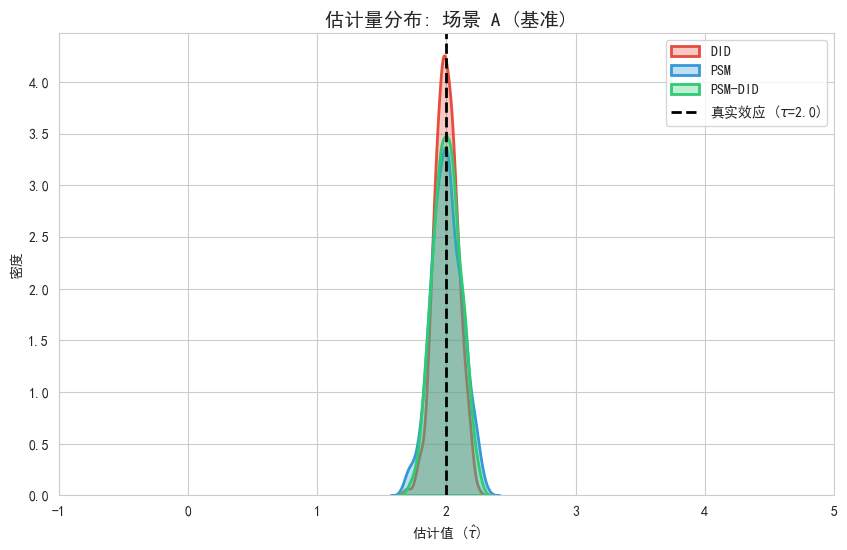

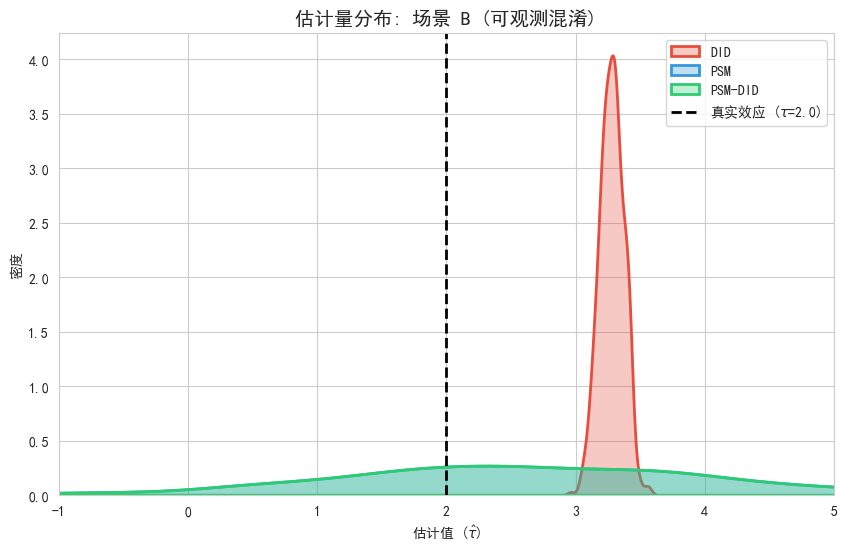

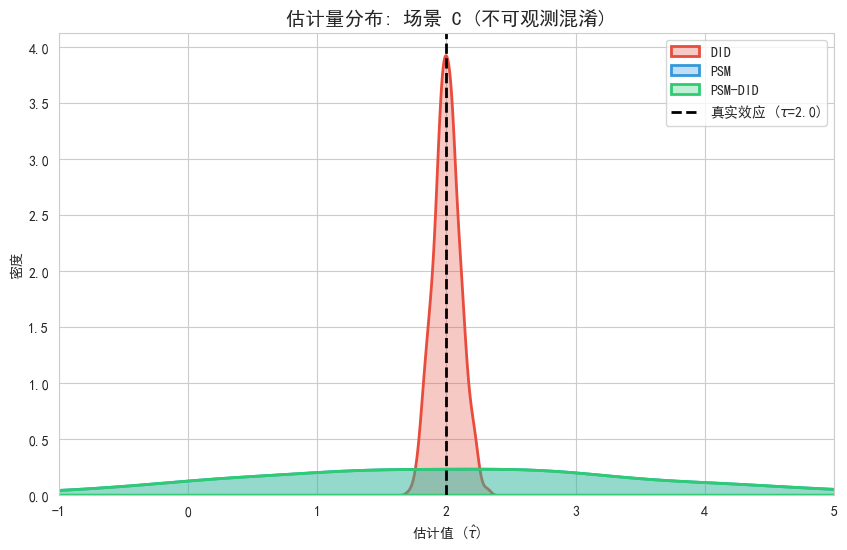

In [ ]:
def plot_simulation_results(res_dict, true_tau, title_suffix):
    """绘制核密度估计图"""
    plt.figure(figsize=(10, 6))
    
    colors = ["#e74c3c", "#3498db", "#2ecc71"] # 红, 蓝, 绿
    for i, (method, vals) in enumerate(res_dict.items()):
        sns.kdeplot(vals, label=method, fill=True, linewidth=2, color=colors[i], alpha=0.3)
    
    plt.axvline(true_tau, color='black', linestyle='--', linewidth=2, label=f'真实效应 ($\\tau$={true_tau})')
    plt.title(f"估计量分布: {title_suffix}", fontsize=14)
    plt.xlabel("估计值 ($\\hat{\\tau}$)")
    plt.ylabel("密度")
    plt.legend()
    plt.xlim(true_tau - 3, true_tau + 3) # 固定X轴范围方便比较
    plt.show()

# 整理数据用于绘图
data_to_plot_A = {
    "DID": sim_results_A["DID"],
    "PSM": sim_results_A["PSM"],
    "PSM-DID": sim_results_A["PSM-DID"]
}

data_to_plot_B = {
    "DID": sim_results_B["DID"],
    "PSM": sim_results_B["PSM"],
    "PSM-DID": sim_results_B["PSM-DID"]
}

data_to_plot_C = {
    "DID": sim_results_C["DID"],
    "PSM": sim_results_C["PSM"],
    "PSM-DID": sim_results_C["PSM-DID"]
}

# 生成并展示图表
print("\n正在生成图表...")
plot_simulation_results(data_to_plot_A, TAU_TRUE, "场景 A (基准)")
plot_simulation_results(data_to_plot_B, TAU_TRUE, "场景 B (可观测混淆)")
plot_simulation_results(data_to_plot_C, TAU_TRUE, "场景 C (不可观测混淆)")

8. 协变量平衡性与共同支持检验

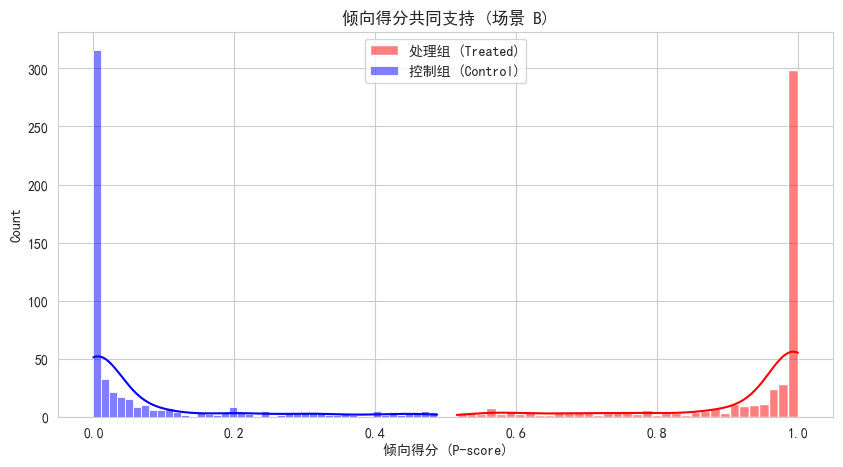


场景 B - 协变量 X 的平衡性检查:
  匹配前标准化偏差: 1.6366
  匹配后标准化偏差: 0.8076


In [27]:
def check_balance_and_common_support(scenario="B"):
    """
    针对某一次具体的模拟，展示匹配前后的协变量平衡和共同支持
    这部分用于放入报告的附录或特定章节
    """
    df = generate_data(scenario)
    
    # --- 1. 共同支持图 (Propensity Score Distribution) ---
    df_pre = df[df['time'] == 0].copy()
    X_pre = df_pre[['X']]
    y_pre = df_pre['treat']
    
    logit = LogisticRegression()
    logit.fit(X_pre, y_pre)
    df_pre['pscore'] = logit.predict_proba(X_pre)[:, 1]
    
    plt.figure(figsize=(10, 5))
    sns.histplot(df_pre[df_pre['treat']==1]['pscore'], color='red', label='处理组 (Treated)', kde=True, alpha=0.5)
    sns.histplot(df_pre[df_pre['treat']==0]['pscore'], color='blue', label='控制组 (Control)', kde=True, alpha=0.5)
    plt.title(f"倾向得分共同支持 (场景 {scenario})")
    plt.xlabel("倾向得分 (P-score)")
    plt.legend()
    plt.show()
    
    # --- 2. 协变量平衡表 ---
    print(f"\n场景 {scenario} - 协变量 X 的平衡性检查:")
    print(f"  匹配前标准化偏差: {np.mean(df_pre[df_pre['treat']==1]['X']) - np.mean(df_pre[df_pre['treat']==0]['X']):.4f}")
    
    # 简单匹配后看看
    treated = df_pre[df_pre['treat']==1]
    control = df_pre[df_pre['treat']==0]
    nn = NearestNeighbors(n_neighbors=1).fit(control[['pscore']])
    idx = nn.kneighbors(treated[['pscore']], return_distance=False).flatten()
    matched_control = control.iloc[idx]
    
    print(f"  匹配后标准化偏差: {np.mean(treated['X']) - np.mean(matched_control['X']):.4f}")

# 运行平衡性检查示例
check_balance_and_common_support("B")